# Trama Urbana
## Del prompt a la publicación
**Proyecto Final · IA: Entretejiendo Imaginación y Algoritmos**  
**Autor:** Lucca Vilas · **Fecha:** 19 de septiembre de 2026

Una prueba de concepto para preparar contenido de Instagram de un emprendimiento ficticio de indumentaria urbana.

### Resumen
Trama Urbana aborda la dificultad de crear contenido claro y visualmente consistente cuando un pequeño emprendimiento dispone de poco tiempo. La propuesta combina generación de texto para redactar publicaciones y generación de imágenes para producir fondos conceptuales. Se utilizan modelos existentes y prompts con contexto, restricciones y formato de salida, sin entrenar un modelo propio.

La entrega reúne una comparación previa de tres prompts, una consulta final que produjo tres publicaciones y tres imágenes generadas a partir de sus instrucciones. La notebook prepara prompts, carga respuestas originales, valida condiciones, registra correcciones, muestra los resultados y exporta los materiales. La generación se realizó en herramientas externas y su incorporación es manual; ejecutar la notebook reproduce el análisis de resultados reales, sin nuevas consultas ni claves API.

### Cómo recorrer la entrega
Ejecutar todas las celdas en orden. El modo **REGISTRO** funciona con las evidencias incluidas. Al final aparecen las tres piezas, la tabla de evaluación y los archivos exportados. La sección de importación explica cómo evaluar una nueva respuesta de ChatGPT. Los fondos son piezas conceptuales: no representan prendas reales ni un catálogo comercial.

## 1. Introducción
### Problema y relevancia
Un emprendimiento de ropa necesita presentar su marca, describir prendas y proponer combinaciones. Preparar cada publicación exige tareas de redacción y diseño que pueden recaer sobre una sola persona. La falta de tiempo puede producir mensajes repetitivos, datos imprecisos y cambios de estilo entre piezas.

Se utiliza el caso ficticio **Trama Urbana**, con remeras y buzos básicos, público de 18 a 30 años y comunicación en español rioplatense. La identidad visual usa beige, negro y blanco. La ficha de producto disponible confirma únicamente una remera negra, lisa y de manga corta. No se conocen precios, telas, talles, disponibilidad o condiciones comerciales.

### Solución y alcance
La POC prepara tres borradores: presentación de marca, presentación de remera e idea de combinación. Cada uno contiene texto, hashtags, un prompt visual y su fondo generado. El texto a texto ayuda a formular el mensaje; el texto a imagen permite explorar una identidad visual sin sustituir una fotografía comercial de la prenda.

Se implementan validación de JSON, controles de extensión y formato, comparación de configuraciones, visualización y exportación. La generación ocurre en ChatGPT web y en el generador de imágenes integrado, con transferencia explícita de resultados. No se automatizan redes sociales, ventas ni una conexión API. Las fotografías reales del catálogo y la publicación comercial quedan fuera de esta POC.

### Viabilidad
Se necesita una computadora, Internet para las herramientas generativas y Jupyter o Colab para ejecutar Python. No se requieren credenciales en el repositorio. La dedicación estimada de planificación es de 6 a 8 horas; no se presenta como tiempo medido. Se utilizaron los accesos disponibles, sin comprar saldo API adicional. La disponibilidad y los límites de generación dependen de la cuenta; no se afirma que esas herramientas sean gratuitas para cualquier usuario.

## 2. Objetivos
**General:** demostrar un procedimiento reproducible para preparar y revisar contenido de un emprendimiento de ropa con modelos de texto y de imagen.

| Objetivo específico | Evidencia de cumplimiento |
|---|---|
| Comparar configuraciones de prompts | Tres respuestas originales del TP 2 y su evaluación |
| Completar el alcance original | Tres textos de 50–80 palabras, hashtags y tres fondos |
| Reducir solicitudes innecesarias | Una consulta final para las tres publicaciones; evaluación local |
| Mejorar la precisión | Revisión editorial separada de la respuesta original |
| Documentar y reproducir la POC | Notebook ejecutada, prompts, datos, imágenes y exportaciones |

No se fija como objetivo demostrar un aumento de ventas ni eliminar la revisión del responsable de la marca.

## 3. Metodología y técnicas
1. Mantener la ficha de marca y producto para limitar invenciones.
2. Recuperar la comparación del TP 2: A básica (zero-shot), B con rol/contexto/restricciones y C con dos ejemplos (few-shot).
3. Elegir B como base y reforzar la prohibición de atribuir comodidad, calidad o disponibilidad no confirmadas.
4. Agrupar las tres publicaciones en una respuesta JSON para evitar repetir el contexto en tres consultas independientes.
5. Guardar la salida original y corregir únicamente lo necesario, conservando el antes y el después.
6. Ejecutar los tres prompts visuales y revisar sus resultados.
7. Validar, mostrar y exportar la campaña desde Python.

### Justificación de las técnicas
En este proyecto, Fast Prompting se aplica como diseño de instrucciones concretas y reutilizables con pocas consultas. **Rol y contexto** orientan tono y audiencia. **Restricciones** delimitan la información conocida. **Few-shot** se compara como alternativa para orientar el estilo. **JSON** facilita la validación. **Agrupación de tareas** obtiene tres borradores en una sola consulta; no es el servicio Batch API. **Descomposición** separa preparación, validación, revisión y exportación en funciones locales.

Las instrucciones explícitas y los ejemplos se apoyan en la [guía oficial de prompting](https://developers.openai.com/es-419/api/docs/guides/prompt-engineering). La definición operativa de Fast Prompting corresponde a este proyecto; no se atribuye una taxonomía no proporcionada al material del curso.

### Herramientas y recursos
Python y bibliotecas estándar; IPython para mostrar tablas e imágenes; Jupyter/Colab para ejecución; ChatGPT web para texto; herramienta integrada `image_gen` para imagen; GitHub para publicar. No se usó DALL·E mediante API. Los identificadores exactos de los modelos no se expusieron y se registran como desconocidos. No se recibió una devolución del TP 2; las mejoras responden a la consigna final y a la revisión del proyecto.

## 4. Implementación: configuración y recursos
Los datos se buscan primero en la carpeta local. Si se abre solamente la notebook en Colab, se descargan los archivos públicos de una versión fija del repositorio. Estas descargas **no son consultas a modelos**. Reejecutar reutiliza los archivos descargados.

`REGISTRO` analiza la campaña ya obtenida. Para evaluar otra respuesta, cambiar a `IMPORTAR` y pegar el JSON original en `RESPUESTA_MANUAL`, entre las comillas triples de la siguiente celda. Las correcciones guardadas solo se aplican al registro original.

In [1]:
import csv
import hashlib
import html
import json
import re
import struct
from pathlib import Path
from urllib.request import urlopen
from IPython.display import display, Markdown, Image

MODO = "REGISTRO"  # REGISTRO o IMPORTAR
RESPUESTA_MANUAL = """"""  # Pegar aquí una respuesta nueva solo en IMPORTAR.
REPOSITORIO = "LuccaVilas/trama-urbana-fast-prompting"
VERSION_DATOS = "d18bff4ec31e3f51471ef610cede3667223c25f3"
BASE_URL = f"https://raw.githubusercontent.com/{REPOSITORIO}/{VERSION_DATOS}/final/"
CACHE = Path(".cache_final")
SALIDA = Path("salidas_final")
SALIDA.mkdir(exist_ok=True)

def cargar_bytes(ruta):
    relativa = Path(ruta)
    if relativa.is_absolute() or ".." in relativa.parts:
        raise ValueError("Usar una ruta relativa de los recursos del proyecto.")
    for base in (Path("."), Path("final"), CACHE):
        archivo = base / relativa
        if archivo.is_file():
            return archivo.read_bytes()
    with urlopen(BASE_URL + relativa.as_posix(), timeout=40) as respuesta:
        contenido = respuesta.read()
    destino = CACHE / relativa
    destino.parent.mkdir(parents=True, exist_ok=True)
    destino.write_bytes(contenido)
    return contenido

def cargar_json(ruta):
    return json.loads(cargar_bytes(ruta).decode("utf-8"))

assert MODO in {"REGISTRO", "IMPORTAR"}
procedencia = cargar_json("datos/procedencia.json")
original = cargar_json("datos/campana_original.json")
campana_revisada = cargar_json("datos/campana_final.json")
revision = cargar_json("datos/revision_editorial.json")
comparacion = cargar_json("datos/comparacion_tp2.json")
imagenes = cargar_json("datos/imagenes.json")
print("Modo:", MODO)
print("Generación de texto:", procedencia["texto"]["herramienta"])
print("Fecha de los resultados finales:", procedencia["fecha"])
print("Recursos cargados. No se hicieron consultas a modelos.")

Modo: REGISTRO
Generación de texto: ChatGPT web
Fecha de los resultados finales: 2026-09-19
Recursos cargados. No se hicieron consultas a modelos.


### 4.1. Prompt reutilizable
El prompt final parte de B, pero agrupa tres objetivos. Puede adaptarse el nombre de la marca mediante la función; las respuestas guardadas corresponden únicamente a Trama Urbana. Si se cambia el caso, hay que generar e importar una respuesta nueva.

In [2]:
# Normalizar saltos de línea para reproducir el mismo prompt en Windows y Colab.
plantilla = cargar_bytes("prompts/texto_campana.txt").decode("utf-8").replace("\r\n", "\n")

def construir_prompt(marca="Trama Urbana"):
    if not isinstance(marca, str) or not marca.strip():
        raise ValueError("La marca debe ser un texto no vacío.")
    return plantilla.replace("Trama Urbana", marca.strip())

prompt_final = construir_prompt()
assert hashlib.sha256(prompt_final.encode()).hexdigest() == procedencia["texto"]["prompt_sha256"]
print(prompt_final)

Actuá como redactor de Trama Urbana, emprendimiento ficticio de ropa urbana. Público de 18 a 30 años; español rioplatense, tono cercano y claro. Prepará TRES borradores para Instagram en una sola respuesta. Datos confirmados: marca Trama Urbana; vende remeras y buzos básicos; producto de referencia: remera negra, lisa, de manga corta. No inventes precio, tela, talles, stock, descuentos, envíos, calidad, comodidad ni durabilidad. No atribuyas características no confirmadas. Las combinaciones con prendas ajenas son ideas, no productos del catálogo.
Devolvé SOLO un objeto JSON con la clave "publicaciones": una lista de exactamente tres objetos. Cada objeto debe tener exactamente las claves "id", "objetivo", "texto", "hashtags", "prompt_imagen". IDs y objetivos: "01" / "Presentación de marca"; "02" / "Presentación de remera"; "03" / "Idea de combinación". Cada texto: 50 a 80 palabras, sin hashtags, menciona Trama Urbana e incluye un llamado a consultar por mensaje privado. El 01 presenta l

### 4.2. Validación sin otra consulta
Se comprueban forma, extensión, hashtags, marca y contacto. Los términos de alerta solo señalan contenido para revisar: no determinan automáticamente si una afirmación es verdadera. La puntuación formal no mide eficacia comercial.

El lector permite una envoltura Markdown de código si la herramienta la agrega, pero conserva el texto original. Rechaza claves duplicadas, IDs repetidos y estructura incorrecta. Una respuesta incorrecta no se reemplaza silenciosamente por ejemplos.

In [3]:
OBJETIVOS = {"01": "Presentación de marca", "02": "Presentación de remera", "03": "Idea de combinación"}
CLAVES = {"id", "objetivo", "texto", "hashtags", "prompt_imagen"}

def objeto_sin_duplicados(pares):
    resultado = {}
    for clave, valor in pares:
        if clave in resultado:
            raise ValueError(f"Clave duplicada: {clave}")
        resultado[clave] = valor
    return resultado

def leer_campana(raw):
    if not isinstance(raw, str) or not raw.strip():
        raise ValueError("Pegá una respuesta JSON no vacía.")
    limpio = raw.strip()
    bloque = re.fullmatch(r"```(?:json)?\s*([\s\S]*?)\s*```", limpio, flags=re.I)
    if bloque:
        limpio = bloque.group(1)
    datos = json.loads(limpio, object_pairs_hook=objeto_sin_duplicados)
    if not isinstance(datos, dict) or set(datos) != {"publicaciones"}:
        raise ValueError("Se esperaba un objeto con la clave publicaciones.")
    publicaciones = datos["publicaciones"]
    if not isinstance(publicaciones, list) or len(publicaciones) != 3:
        raise ValueError("Se requieren exactamente tres publicaciones.")
    ids = []
    for p in publicaciones:
        if not isinstance(p, dict) or set(p) != CLAVES:
            raise ValueError("Las claves de una publicación son incorrectas.")
        if not all(isinstance(p[k], str) for k in CLAVES - {"hashtags"}):
            raise ValueError("Los campos de texto deben ser strings.")
        if not isinstance(p["hashtags"], list) or not all(isinstance(h, str) for h in p["hashtags"]):
            raise ValueError("Hashtags debe ser una lista de strings.")
        if p["id"] not in OBJETIVOS or p["objetivo"] != OBJETIVOS[p["id"]]:
            raise ValueError("ID u objetivo no reconocido.")
        ids.append(p["id"])
    if len(set(ids)) != 3:
        raise ValueError("Los IDs deben ser únicos.")
    return datos

def evaluar_publicacion(p):
    texto = p["texto"]
    palabras = len(texto.split())
    controles = {
        "extension": 50 <= palabras <= 80,
        "hashtags": 1 <= len(p["hashtags"]) <= 3 and all(re.fullmatch(r"#\w+", h) for h in p["hashtags"]),
        "marca": "trama urbana" in texto.lower(),
        "contacto": "mensaje privado" in texto.lower(),
        "prompt_visual": bool(p["prompt_imagen"].strip()),
    }
    alertas = [termino for termino in ["cómod", "calidad", "algodón", "descuento", "disponible", "empezando"]
               if termino in texto.lower()]
    return {"id": p.get("id", ""), "palabras": palabras,
            "puntos_formales": sum(bool(v) for v in controles.values()),
            "controles": {k: bool(v) for k, v in controles.items()}, "alertas_para_revisar": alertas}

def tabla(filas, columnas):
    def celda(v):
        return str(v).replace("|", "/").replace("\n", " ")
    encabezado = "| " + " | ".join(columnas) + " |"
    separador = "| " + " | ".join("---" for _ in columnas) + " |"
    cuerpo = ["| " + " | ".join(celda(f[c]) for c in columnas) + " |" for f in filas]
    display(Markdown("\n".join([encabezado, separador] + cuerpo)))

### 4.3. Comparación de prompts del TP 2
Estas respuestas se obtuvieron en tres conversaciones independientes el 10/09/2026. Se recalculan sus métricas con la misma función. Todas cumplían el formato, pero A atribuía comodidad a la prenda. B fue la base seleccionada; C agregó instrucciones sin una mejora clara en esa muestra.

La comparación es exploratoria: una respuesta por variante y un solo caso no permiten probar superioridad general ni aislar causalmente cada técnica. No se compara el modo Instantánea de la sesión final con un modelo identificable del TP 2.

In [4]:
filas_tp2 = []
for nombre, registro in comparacion["respuestas"].items():
    respuesta = json.loads(registro["raw"])
    medida = evaluar_publicacion(respuesta)
    filas_tp2.append({"variante": nombre, "caracteres_prompt": len(registro["prompt"]),
                     "palabras": medida["palabras"], "formato_sobre_5": medida["puntos_formales"],
                     "alertas": ", ".join(medida["alertas_para_revisar"]) or "Ninguna detectada"})
tabla(filas_tp2, ["variante", "caracteres_prompt", "palabras", "formato_sobre_5", "alertas"])

| variante | caracteres_prompt | palabras | formato_sobre_5 | alertas |
| --- | --- | --- | --- | --- |
| A_basico | 611 | 60 | 5 | cómod |
| B_contexto | 869 | 56 | 5 | Ninguna detectada |
| C_few_shot | 1296 | 56 | 5 | cómod |

### 4.4. Respuesta final original y revisión editorial
La consulta del 19/09/2026 devolvió los tres borradores en una respuesta. El registro original se conserva sin cambios. La revisión editorial asistida por IA quitó una historia no confirmada sobre la etapa inicial de la marca y una frase que podía sugerir disponibilidad de stock. No se gastó otra consulta en esas correcciones.

Las observaciones editoriales son juicios de revisión, no respuestas adicionales de ChatGPT. El responsable del emprendimiento debe aprobar cualquier publicación comercial.

In [5]:
raw_original = cargar_bytes("datos/respuesta_original.txt").decode("utf-8")
assert leer_campana(raw_original) == original
print("RESPUESTA ORIGINAL (sin corrección):")
print(json.dumps(original, ensure_ascii=False, indent=2))
tabla([{"id": c["id"], "motivo": c["motivo"]} for c in revision], ["id", "motivo"])

if MODO == "REGISTRO":
    campana = leer_campana(json.dumps(campana_revisada, ensure_ascii=False))
else:
    campana = leer_campana(RESPUESTA_MANUAL)
    print("Nueva respuesta importada. No se aplicaron las correcciones de la campaña anterior.")

evaluaciones = [evaluar_publicacion(p) for p in campana["publicaciones"]]
filas_final = [{"id": e["id"], "palabras": e["palabras"], "formato_sobre_5": e["puntos_formales"],
                "alertas": ", ".join(e["alertas_para_revisar"]) or "Ninguna detectada"} for e in evaluaciones]
tabla(filas_final, ["id", "palabras", "formato_sobre_5", "alertas"])
print("Sin alertas automáticas no significa ausencia garantizada de información inventada.")

RESPUESTA ORIGINAL (sin corrección):
{
  "publicaciones": [
    {
      "id": "01",
      "objetivo": "Presentación de marca",
      "texto": "Trama Urbana nace para quienes buscan sumar básicos a su día a día sin dar demasiadas vueltas. Remeras y buzos de líneas simples, pensados para formar parte de distintos looks y momentos. Estamos empezando a construir nuestra identidad y queremos que seas parte. Si querés conocer más sobre Trama Urbana y nuestras prendas, escribinos por mensaje privado y te contamos.",
      "hashtags": [
        "#TramaUrbana",
        "#RopaUrbana",
        "#BasicosUrbanos"
      ],
      "prompt_imagen": "Fondo conceptual cuadrado de campaña, no producto real. Fotografía editorial minimalista con paleta beige, negro y blanco, luz suave y espacio central amplio libre. Composición arquitectónica baja con formas geométricas ubicadas en los bordes. Sin prendas, personas, texto, letras, logotipos, marcas de agua ni columnas verticales. Estética urbana, limpia y c

| id | motivo |
| --- | --- |
| 01 | Se quitó la historia no confirmada sobre el nacimiento y la etapa inicial de la marca; se mantuvo la presentación con los datos de la ficha. |
| 02 | Se evitó que la frase final sugiriera disponibilidad de productos no verificada. |

| id | palabras | formato_sobre_5 | alertas |
| --- | --- | --- | --- |
| 01 | 59 | 5 | Ninguna detectada |
| 02 | 61 | 5 | Ninguna detectada |
| 03 | 64 | 5 | Ninguna detectada |

Sin alertas automáticas no significa ausencia garantizada de información inventada.


### 4.5. Integración texto a imagen
Cada prompt visual fue enviado al generador integrado `image_gen`; se realizaron tres generaciones independientes. Los PNG originales están en `final/imagenes/` y los prompts en `final/prompts/`. No se retocaron las imágenes. La notebook verifica integridad, dimensiones y formato; la revisión visual está registrada por separado.

En la imagen 01 el modelo agregó cielo, agua y una roca. Se acepta como fondo conceptual, pero no cumple una eventual exigencia de estudio cerrado que no estaba en el prompt. La imagen 02 deja libre el centro y evita columnas; la 03 usa paneles planos en vista cenital. Se mantuvo la paleta general, con variaciones de iluminación.

In [6]:
archivos_imagen = {}
filas_imagen = []
for registro in imagenes:
    contenido = cargar_bytes(registro["archivo"])
    if contenido[:8] != b"\x89PNG\r\n\x1a\n":
        raise ValueError("El archivo no tiene firma PNG.")
    ancho, alto = struct.unpack(">II", contenido[16:24])
    assert hashlib.sha256(contenido).hexdigest() == registro["sha256"], "Imagen modificada respecto del registro."
    assert (ancho, alto) == (registro["ancho"], registro["alto"])
    archivos_imagen[registro["id"]] = contenido
    filas_imagen.append({"id": registro["id"], "dimensiones": f"{ancho} × {alto}",
                         "cuadrada": ancho == alto, "integridad": "SHA-256 coincide"})
tabla(filas_imagen, ["id", "dimensiones", "cuadrada", "integridad"])

| id | dimensiones | cuadrada | integridad |
| --- | --- | --- | --- |
| 01 | 1254 × 1254 | True | SHA-256 coincide |
| 02 | 1254 × 1254 | True | SHA-256 coincide |
| 03 | 1254 × 1254 | True | SHA-256 coincide |

## 5. Resultados: tres propuestas de publicación
Cada pieza se muestra con su texto revisado, hashtags y fondo conceptual. Los espacios vacíos permiten incorporar posteriormente fotografías reales; no se inventó un catálogo para completar la imagen. Si se usa IMPORTAR, las imágenes que siguen pertenecen al registro original y no se presentan como nuevas generaciones.

### 01 · Presentación de marca

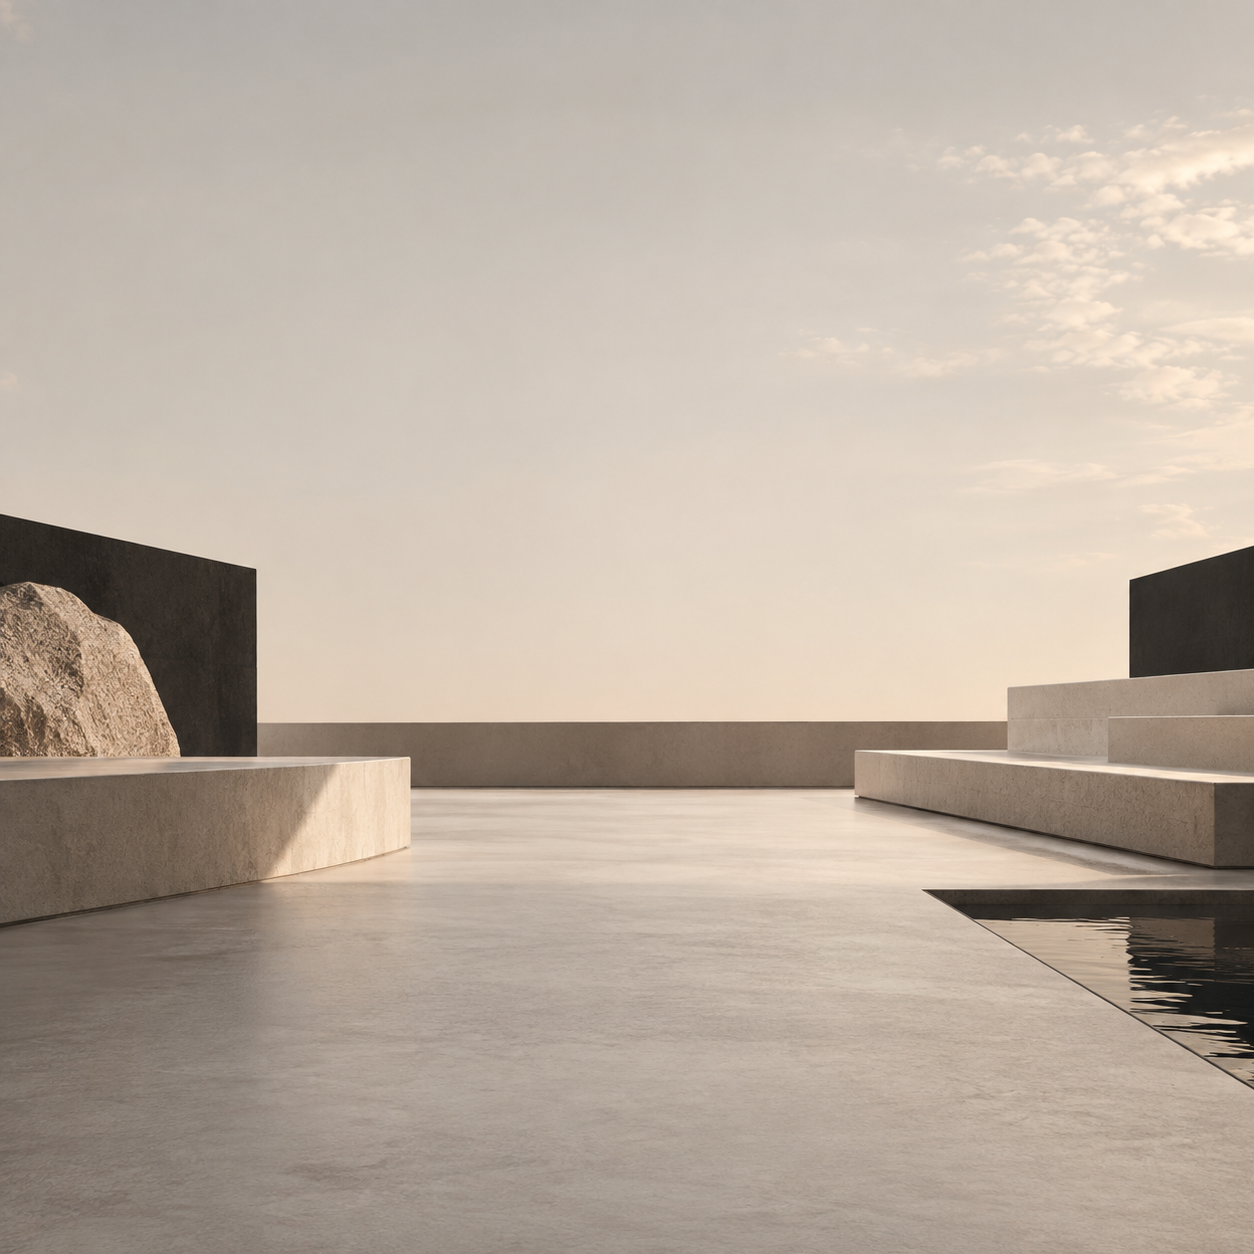

En Trama Urbana encontrás remeras y buzos básicos para pensar tus próximas combinaciones. Las prendas simples pueden ser el punto de partida de distintos looks y momentos. Este espacio reúne ideas para elegir y combinar esas prendas según tu estilo. Si querés conocer más sobre Trama Urbana y su propuesta, escribinos por mensaje privado y contanos qué estás buscando.

#TramaUrbana #RopaUrbana #BasicosUrbanos

**Prompt utilizado para esta imagen:** Fondo conceptual cuadrado de campaña, no producto real. Fotografía editorial minimalista con paleta beige, negro y blanco, luz suave y espacio central amplio libre. Composición arquitectónica baja con formas geométricas ubicadas en los bordes. Sin prendas, personas, texto, letras, logotipos, marcas de agua ni columnas verticales. Estética urbana, limpia y coherente con una campaña visual contemporánea.

### 02 · Presentación de remera

Una idea simple para armar un look: combinar la remera negra, lisa y de manga corta de Trama Urbana con un jean y zapatillas blancas. El jean y las zapatillas son solo una propuesta de combinación y no forman parte del catálogo mencionado. Podés tomar la idea y adaptarla a tu estilo. Para consultar por la remera de Trama Urbana, escribinos por mensaje privado.

#TramaUrbana #IdeaDeLook #EstiloUrbano

**Prompt utilizado para esta imagen:** Fondo conceptual cuadrado de campaña, no producto real. Fotografía editorial minimalista en vista cenital, paleta beige, negro y blanco, luz suave y espacio central amplio libre. Paneles planos beige, negros y blancos distribuidos alrededor del centro sin invadirlo. Sin prendas, personas, texto, letras, logotipos, marcas de agua ni columnas verticales. Conservar la misma estética urbana, limpia y contemporánea de la campaña.

In [7]:
for p in sorted(campana["publicaciones"], key=lambda item: item["id"]):
    display(Markdown(f"### {p['id']} · {p['objetivo']}"))
    display(Image(data=archivos_imagen[p["id"]], width=480))
    display(Markdown(p["texto"] + "\n\n" + " ".join(p["hashtags"])))
    if MODO == "REGISTRO":
        assert p["prompt_imagen"] == next(i["prompt"] for i in imagenes if i["id"] == p["id"])
        display(Markdown("**Prompt utilizado para esta imagen:** " + p["prompt_imagen"]))
    else:
        display(Markdown("**Imagen de referencia del registro; no fue generada con el nuevo prompt importado.**"))

## 6. Exportación y comprobación del código
Se exportan JSON y CSV para conservar contenido y métricas. También se genera una galería HTML local con textos e imágenes para revisar los borradores. Los datos se escapan antes de insertarlos en HTML.

Las pruebas negativas comprueban que se rechacen respuestas mal formadas. No son pruebas de calidad del modelo ni de eficacia publicitaria.

In [8]:
(SALIDA / "campana.json").write_text(json.dumps(campana, ensure_ascii=False, indent=2), encoding="utf-8")
(SALIDA / "evaluacion.json").write_text(json.dumps(evaluaciones, ensure_ascii=False, indent=2), encoding="utf-8")
with (SALIDA / "evaluacion.csv").open("w", newline="", encoding="utf-8") as archivo:
    escritor = csv.DictWriter(archivo, fieldnames=["id", "palabras", "formato_sobre_5", "alertas"])
    escritor.writeheader()
    escritor.writerows(filas_final)

tarjetas = []
for p in sorted(campana["publicaciones"], key=lambda item: item["id"]):
    nombre_imagen = p["id"] + ".png"
    (SALIDA / nombre_imagen).write_bytes(archivos_imagen[p["id"]])
    tarjetas.append(
        f'<article><div class="numero">{html.escape(p["id"])}</div>'
        f'<h2>{html.escape(p["objetivo"])}</h2>'
        f'<img src="{nombre_imagen}" alt="Fondo conceptual {html.escape(p["id"])}">'
        f'<p>{html.escape(p["texto"])}</p><small>{html.escape(" ".join(p["hashtags"]))}</small></article>'
    )
estilo = """*{box-sizing:border-box}body{margin:0;background:#f4f0e8;color:#222;font:17px/1.65 system-ui,sans-serif}
header,main,footer{width:100%;max-width:1120px;margin:auto;padding:36px}h1{font-size:52px;line-height:1.1;margin:14px 0}
header small,.numero{letter-spacing:.16em;text-transform:uppercase}main{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:24px}
article{min-width:0;background:#fff;padding:22px;border-top:4px solid #222}h2{font-size:22px;min-height:60px}img{display:block;width:100%;height:auto}
small{color:#62594b}footer{border-top:1px solid #c4bbaa}@media(max-width:800px){main{grid-template-columns:1fr}h1{font-size:38px}}"""
aviso = "Tres borradores revisados · Imágenes conceptuales generadas con IA"
if MODO == "IMPORTAR":
    aviso = "Respuesta importada, pendiente de revisión · Fondos del registro original"
galeria = ('<!doctype html><html lang="es"><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">'
           '<title>Trama Urbana · Campaña</title><style>' + estilo + '</style><header><small>Proyecto final / Prompt engineering</small>'
           '<h1>Trama Urbana</h1><p>' + aviso + '</p></header><main>' + ''.join(tarjetas) + '</main>'
           '<footer>Prototipo académico de una marca ficticia. Los fondos no muestran productos reales. '
           'La publicación comercial requiere revisión y fotografías del catálogo.</footer></html>')
(SALIDA / "galeria.html").write_text(galeria, encoding="utf-8")

def debe_fallar(contenido):
    try:
        leer_campana(contenido)
    except (ValueError, TypeError):
        return
    raise AssertionError("Se aceptó una estructura incorrecta.")

debe_fallar("no es JSON")
debe_fallar('{"publicaciones": []}')
debe_fallar('{"publicaciones": [], "publicaciones": []}')
duplicada = json.loads(json.dumps(original))
duplicada["publicaciones"][1]["id"] = "01"
duplicada["publicaciones"][1]["objetivo"] = OBJETIVOS["01"]
debe_fallar(json.dumps(duplicada))
assert leer_campana("```json\n" + raw_original + "\n```") == original
if MODO == "REGISTRO":
    assert len(campana["publicaciones"]) == 3
    assert all(e["puntos_formales"] == 5 for e in evaluaciones)
    assert all(not e["alertas_para_revisar"] for e in evaluaciones)
print("Validación completada: estructura, IDs, JSON inválido e integridad de las tres imágenes.")
print("Exportaciones:", str(SALIDA.resolve()))

Validación completada: estructura, IDs, JSON inválido e integridad de las tres imágenes.
Exportaciones: C:\Users\Lucca\Documents\ChatGPT\Inteligencia artificial_ Generación de Prompts\Proyecto-Final-Trama-Urbana\salidas_final


## 7. Resultados y uso de recursos
Los valores y conclusiones de esta sección corresponden al registro final entregado. Al importar otra respuesta, se deben revisar sus nuevas tablas y actualizar el análisis; estas conclusiones no cambian automáticamente.

La implementación produjo tres publicaciones con textos revisados de **59, 61 y 64 palabras**, hashtags y tres fondos de **1254 × 1254 píxeles**. Las tres piezas cumplen los cinco controles formales. La revisión identificó dos ajustes en el texto original, lo que muestra por qué esos controles no reemplazan la lectura del contenido.

| Etapa | Solicitudes de texto | Generaciones de imagen |
|---|---:|---:|
| TP 1, prueba visual previa | — | 1 |
| TP 2, comparación A/B/C | 3 | 0 |
| Final, producción agrupada | 1 | 3 |
| Reejecutar esta notebook en REGISTRO | 0 | 0 |

La prueba preliminar de texto del TP 1 se realizó en la conversación de asistencia y no forma parte de un registro de consultas API. La tabla distingue los experimentos documentados; no representa toda la interacción de desarrollo.

Agrupar los tres borradores requirió una consulta de texto final. Frente a un diseño hipotético de una consulta por publicación serían dos solicitudes menos, pero no se midieron ahorro monetario ni tiempo. Los tokens y el costo imputable por generación no estuvieron disponibles. No hubo compra adicional de saldo API para esta entrega. Generar la notebook y revisar su código también implicó asistencia de IA y no se incluye en el conteo del experimento de publicaciones.

El problema se resuelve dentro del alcance de una **POC de borradores**: ya existe un conjunto coherente para revisar y adaptar. No se demostró que sustituya un diseñador, que elimine errores o que aumente ventas. Las imágenes 01 y 02 no son idénticas en iluminación; la coherencia de paleta no garantiza uniformidad total.

## 8. Conclusiones
Se cumplieron los objetivos de aplicar texto a texto y texto a imagen a una necesidad concreta, completar tres propuestas y documentar una notebook que procesa evidencias reales. La comparación inicial orientó la elección del prompt con contexto; la producción agrupada permitió extenderlo a los tres objetivos previstos.

El resultado más relevante es un procedimiento verificable: instrucciones explícitas, salida original conservada, comprobaciones con Python y revisión editorial. Los modelos no evitaron por completo afirmaciones no confirmadas, por lo que se mantuvo la intervención de revisión. Las imágenes funcionan como fondos conceptuales y necesitan fotografías auténticas si se transforman en anuncios de productos reales.

La propuesta es viable con herramientas existentes y sin una integración API obligatoria. Su principal límite es que la generación y la transferencia son externas y manuales. La ejecución de la notebook reproduce la evaluación, visualización y exportación; no genera nuevas respuestas por sí sola. Una ampliación futura podría conectar una API con presupuesto y probar más productos, pero esa funcionalidad no se presenta como implementada en esta entrega final.

### Mejoras respecto del TP 2
- Se completaron las tres publicaciones y se generaron tres imágenes nuevas.
- Se agruparon los textos en una consulta y se documentaron las correcciones.
- Se agregaron verificación de archivos, exportación y pruebas de entradas inválidas.
- Se separaron con claridad la generación externa y la ejecución de la notebook.
- Se retiró la conexión API no verificada del flujo principal final; el TP 2 permanece como antecedente.

### Alcance de la evidencia
Las pruebas son pequeñas y exploratorias; no permiten generalizar rendimiento. No se conoce el identificador exacto de los modelos. La revisión fue asistida por IA y no reemplaza la aprobación de quien use los materiales. La consigna recibida no incluía el detalle de la rúbrica después de su encabezado, por lo que la correspondencia se basa en los requisitos explícitos suministrados.

## 9. Referencias y procedencia
- Consigna del Proyecto Final: *IA: Entretejiendo Imaginación y Algoritmos*, proporcionada en el curso.
- OpenAI. [Ingeniería de prompts](https://developers.openai.com/es-419/api/docs/guides/prompt-engineering). Consultada el 19/09/2026; se usa para fundamentar instrucciones y ejemplos.
- Proyecto Jupyter. [Ejecución de notebooks con nbclient](https://nbclient.readthedocs.io/en/latest/client.html). Consultada el 19/09/2026; se utiliza para la verificación de ejecución.
- Evidencias del proyecto: `final/datos/`, `final/prompts/` y `final/imagenes/` en el repositorio. Se conservan las respuestas originales, los prompts exactos, las correcciones y los PNG generados.

Se utilizó asistencia de IA para redacción, código, generación y revisión. Trama Urbana es un caso ficticio y no se utilizaron datos de clientes. Los fondos fueron generados con la herramienta integrada `image_gen`, sin solicitar la API de DALL·E ni asumir un nombre de modelo no expuesto.